# PLANT LEAF DISEASE DETECTION

# 1. Business Understanding

## 1.1 Project Overview

Agriculture is a key pillar of food security and economic growth globally and particularly in developing countries where a large percentage of the population depends on farming for their livelihood. However, crop diseases remain one of the major threats to agricultural productivity, leading to reduced yields, financial losses, and food insecurity.

In this project, we focus on the detection of plant leaf diseases in corn, tomato, and potato crops using image classification techniques. The goal is to build a machine learning model capable of identifying whether a plant leaf is healthy or diseased based on visual symptoms. By automating disease detection, farmers can take timely action to prevent disease spread, improve crop health, and reduce reliance on manual inspection, which is often slow, inaccurate, and requires expert knowledge.

## 1.2 Problem Statement

Crop diseases such as blight, leaf spots, and rust significantly affect the productivity of corn, tomato, and potato plants. Traditional disease detection relies heavily on manual observation by farmers or agricultural experts, which is both time-consuming and prone to human error.

There is therefore a need for a technological solution that can accurately and efficiently detect and classify plant leaf diseases at an early stage. This will help farmers make informed decisions on disease management, reduce crop losses, and improve overall agricultural productivity.

## 1.3 Business Objectives

### 1.3.1 Main Objective

To develop an image classification model that can automatically detect and classify leaf diseases in corn, tomato, and potato plants.

### 1.3.2 Specific Objectives

- To collect and preprocess images of corn, tomato, and potato leaves (both healthy and diseased).

- To train and evaluate a machine learning model capable of identifying disease types based on leaf images.

- To compare model performance using different classification algorithms.

- To provide a simple, user-friendly interface that can assist farmers in identifying crop diseases through image uploads.

### 1.3.3 Research Questions

- What types of diseases affect corn, tomato, and potato leaves?

- Can image classification accurately identify diseased leaves?

- Which model gives the best results in detecting plant leaf diseases?

- How can the model’s results be presented in a way that is easy for farmers to understand?

## 1.4 Success Criteria

- The model achieves an accuracy of 90% or higher on test images.

- It correctly identifies and classifies diseases in all three crops.

- It has a low number of false results (wrong predictions).

- A simple system or interface is developed for easy use by farmers.

# 2. Data Understanding

The dataset used in this project comes from [Mendeley Data — “PlantVillage Dataset: Potato Leaf Disease”](https://data.mendeley.com/datasets/tywbtsjrjv/1)

It contains labeled images of potato leaves under 16 categories


Data Summary:
- Total images: 27381 original images.
- Classes: 16
- Format: JPEG
- Resolution: Variable, to be resized to 224×224 for model training
- Image collection: Captured under field and controlled lighting conditions

## Loading Our Dataset

In [1]:
import tensorflow as tf
import os

# Path to your dataset folder
dataset_path = "Plant disease dataset"

# Load dataset 
data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),   
    batch_size=32,
    shuffle=True
)

# Show all class names
print("Classes found:")
print(data.class_names)

Found 27381 files belonging to 16 classes.
Classes found:
['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy_aug', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


## Counting all Images in each class

In [2]:
# count of images from all our classes

dataset_path = "Plant disease dataset"

# Get class names (subfolders)
classes = sorted(os.listdir(dataset_path))

# Count images in each class
print("Class Counts:\n")
for class_name in classes:
    class_dir = os.path.join(dataset_path, class_name)
    count = len(os.listdir(class_dir))
    print(f"{class_name}: {count} images")

Class Counts:

Corn___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Corn___Common_rust: 1192 images
Corn___Northern_Leaf_Blight: 985 images
Corn___healthy: 1162 images
Potato___Early_blight: 2496 images
Potato___Late_blight: 2500 images
Potato___healthy_aug: 2500 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1909 images
Tomato___Leaf_Mold: 952 images
Tomato___Septoria_leaf_spot: 1771 images
Tomato___Spider_mites Two-spotted_spider_mite: 1676 images
Tomato___Target_Spot: 1404 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 images
Tomato___Tomato_mosaic_virus: 373 images
Tomato___healthy: 1591 images


## Checking for duplicates

In [3]:
# To check and count duplicates
import tensorflow as tf
import hashlib

def count_duplicates(dataset):
    seen = set()
    duplicates = 0
    
    for images, _ in dataset:
        for img in images:
            img_hash = hashlib.md5(img.numpy().tobytes()).hexdigest()
            if img_hash in seen:
                duplicates += 1
            else:
                seen.add(img_hash)
    
    print(f"Unique images: {len(seen)}")
    print(f"Duplicate images: {duplicates}")

# Using the function
count_duplicates(data)


Unique images: 27367
Duplicate images: 14


## Checking for corrupt images

In [4]:
from PIL import Image

corrupted_images = []

for c in classes:
    class_path = os.path.join(dataset_path, c)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  
        except Exception as e:
            corrupted_images.append(img_path)

print(f"Total corrupted images found: {len(corrupted_images)}")

if corrupted_images:
    print("Some images are corrupted. Example:")
    print(corrupted_images[:5])
else:
    print("No corrupted images found.")

Total corrupted images found: 0
No corrupted images found.


# 3. EDA

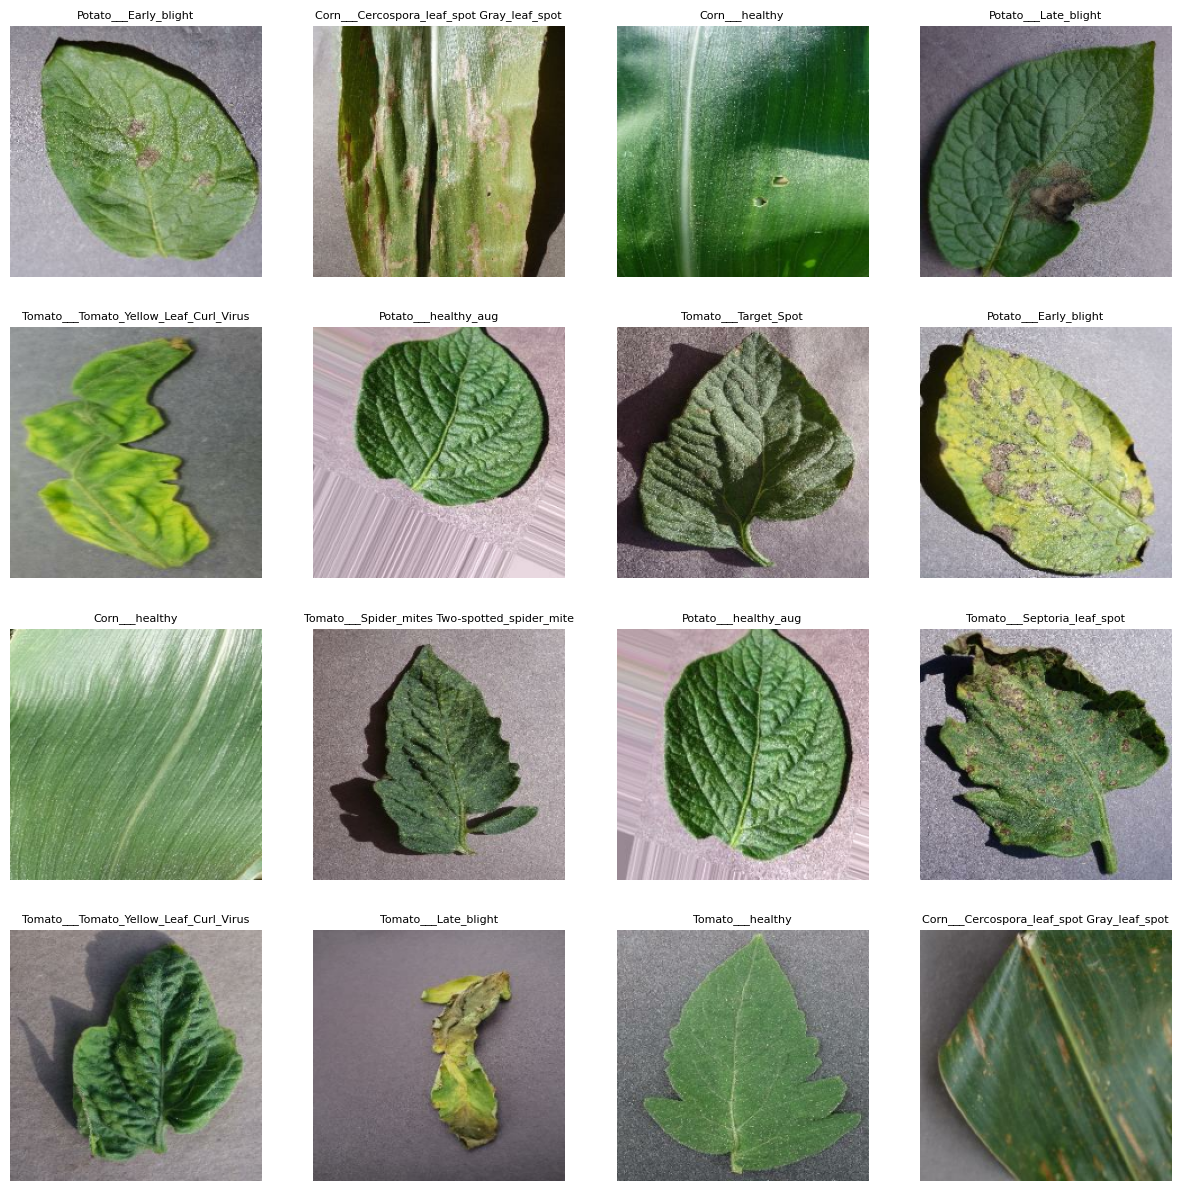

In [5]:
# Preview of random images from our classes 
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
for images, labels in data.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(data.class_names[labels[i]], fontsize=8)
        plt.axis("off")
plt.show()

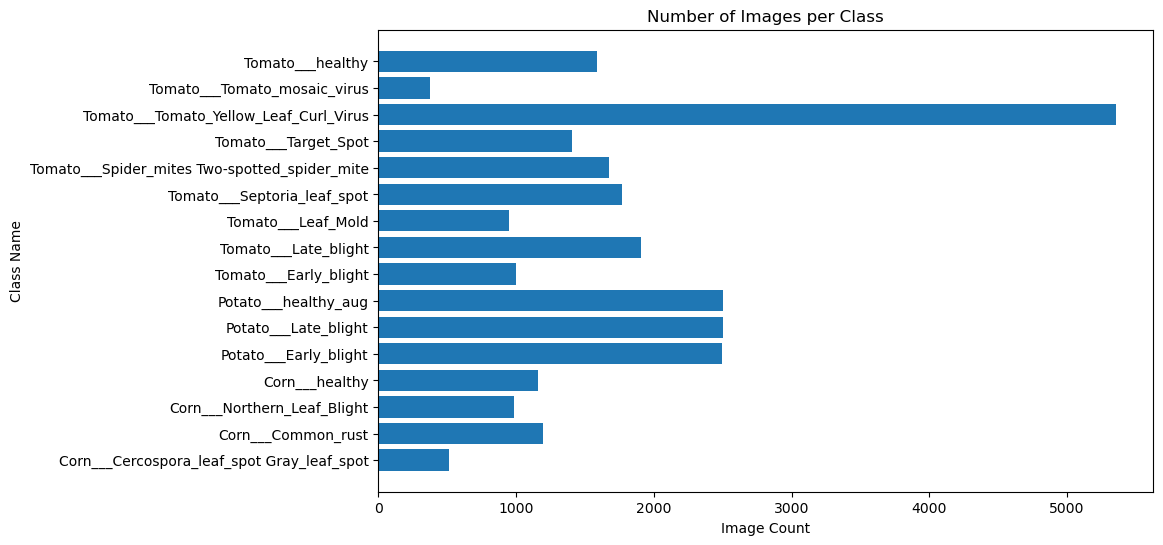

In [6]:
# count of the 16 classes
plt.figure(figsize=(10,6))
plt.barh(classes, [len(os.listdir(os.path.join(dataset_path, c))) for c in classes])
plt.title("Number of Images per Class")
plt.xlabel("Image Count")
plt.ylabel("Class Name")
plt.show()

In [7]:
# 
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

def check_image_sizes(dataset, class_names):
    """Check image sizes for each class in a TensorFlow dataset"""
    sizes_per_class = {class_name: [] for class_name in class_names}
    
    for images, labels in dataset:
        for i in range(len(images)):
            height, width, channels = images[i].shape
            class_name = class_names[labels[i]]
            sizes_per_class[class_name].append((width, height))
    
    return sizes_per_class


In [8]:
# Usage
sizes_dict = check_image_sizes(data, data.class_names)

# Print results
for class_name, sizes in sizes_dict.items():
    if sizes:  
        widths, heights = zip(*sizes)
        print(f"Class: {class_name}")
        print(f"  Count: {len(sizes)}")
        print(f"  Width range: {min(widths)} - {max(widths)}")
        print(f"  Height range: {min(heights)} - {max(heights)}")
        print(f"  Avg size: {np.mean(widths):.1f} x {np.mean(heights):.1f}")

Class: Corn___Cercospora_leaf_spot Gray_leaf_spot
  Count: 513
  Width range: 224 - 224
  Height range: 224 - 224
  Avg size: 224.0 x 224.0
----------------------------------------
Class: Corn___Common_rust
  Count: 1192
  Width range: 224 - 224
  Height range: 224 - 224
  Avg size: 224.0 x 224.0
----------------------------------------
Class: Corn___Northern_Leaf_Blight
  Count: 985
  Width range: 224 - 224
  Height range: 224 - 224
  Avg size: 224.0 x 224.0
----------------------------------------
Class: Corn___healthy
  Count: 1162
  Width range: 224 - 224
  Height range: 224 - 224
  Avg size: 224.0 x 224.0
----------------------------------------
Class: Potato___Early_blight
  Count: 2496
  Width range: 224 - 224
  Height range: 224 - 224
  Avg size: 224.0 x 224.0
----------------------------------------
Class: Potato___Late_blight
  Count: 2500
  Width range: 224 - 224
  Height range: 224 - 224
  Avg size: 224.0 x 224.0
----------------------------------------
Class: Potato___heal

# 4. Data Preparation

## Removing Duplicates

In [12]:
# Removing  duplicates
def remove_duplicates(dataset):
    seen = set()
    clean_images, clean_labels = [], []
    
    for images, labels in dataset:
        for i, img in enumerate(images):
            h = hashlib.md5(img.numpy().tobytes()).hexdigest()
            if h not in seen:
                seen.add(h)
                clean_images.append(img)
                clean_labels.append(labels[i])
    
    return tf.data.Dataset.from_tensor_slices(
        (tf.stack(clean_images), tf.stack(clean_labels))
    )

# Using the function

data = remove_duplicates(data)
print("Done")



Done


## Dealing with Class Imbalance

In [14]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights automatically
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

# Convert to dictionary for Keras
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 3.3358918128654973, 1: 1.4356648489932886, 2: 1.7373730964467005, 3: 1.4727302065404475, 4: 0.6856219951923077, 5: 0.684525, 6: 0.684525, 7: 1.7113125, 8: 0.8964444735463594, 9: 1.7975971638655461, 10: 0.9662972896668549, 11: 1.0210695107398569, 12: 1.218883547008547, 13: 0.31945351876050027, 14: 4.587969168900805, 15: 1.0756206788183533}
